
# Research Paper Implementation with Pre-trained Models

**Course Name:** Generative AI

**Lab Title:** Image Classification using CNN and Transfer Learning

**Student Name:** Amruta Sunil Kanase

**PRN:** 202401110042

**Group Members:** Sanika Mane(202401110047),Tanishka Tapkir(202401110071)


# Research Paper Study and Implementation

## Research Paper

**Title:** Comparing pre-trained models for efficient leaf disease detection: a study on custom CNN

**Authors:** Touhidul Seyam Alam, Chandni Barua Jowthi and Abhijit Pathak

**Journal:** Journal of Electrical Systems and Information Technology

**Year:** 2024

**DOI:** 10.1186/s43067-024-00137-1

## Research Paper Link

https://link.springer.com/article/10.1186/s43067-024-00137-1

# Task 1 — Research Paper Selection and Dataset Preparation

## Step 1: Import Required Libraries

The following libraries are imported for:

- Dataset processing
- CNN construction
- Transfer learning
- Model training
- Evaluation
- Visualization
- Performance comparison

In [24]:
import os
import time
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.applications import (
    MobileNetV2,
    ResNet50
)

from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input as mobilenet_preprocess
)

from tensorflow.keras.applications.resnet50 import (
    preprocess_input as resnet_preprocess
)

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("TensorFlow Version:", tf.__version__)
print("GPU Devices:", tf.config.list_physical_devices("GPU"))

TensorFlow Version: 2.20.0
GPU Devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 2: Install Kaggle API

The PlantVillage dataset is downloaded directly from Kaggle.

The Kaggle API package is installed so that the dataset can be downloaded into the Colab environment.

In [25]:
!pip install -q kaggle

## Step 3: Kaggle Authentication

Kaggle authentication is required to download the dataset.

For this notebook, the Kaggle API token is entered through Google Colab Secrets instead of hard-coding the token in the notebook.

This prevents the API credential from being exposed in the submitted notebook.

In [26]:
from google.colab import userdata

os.environ["KAGGLE_API_TOKEN"] = userdata.get(
    "KAGGLE_API_TOKEN"
)

print("Kaggle API token loaded successfully.")

Kaggle API token loaded successfully.


## Step 4: Download PlantVillage Dataset

The PlantVillage dataset is downloaded from Kaggle.

The dataset contains images of diseased and healthy plant leaves from multiple crops.

Only the tomato classes will be used for this experiment.

In [27]:
!kaggle datasets download \
    -d abdallahalidev/plantvillage-dataset \
    -p /content

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
plantvillage-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


## Step 5: Extract Dataset

The downloaded ZIP file is extracted into the Colab working directory.

The extracted dataset contains different representations of PlantVillage images.

The `color` directory is used because the disease information is represented through leaf color and visible symptoms.

In [28]:
import zipfile
from pathlib import Path

zip_path = "/content/plantvillage-dataset.zip"
extract_path = "/content/plantvillage_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")
print("Extraction directory:", extract_path)

Dataset extracted successfully.
Extraction directory: /content/plantvillage_dataset


## Step 6: Locate the Color Dataset

The Kaggle PlantVillage archive contains multiple folders.

This cell searches for the `color` directory so that the correct image dataset path can be identified automatically rather than assuming a fixed path.

In [29]:
color_dirs = list(
    Path("/content/plantvillage_dataset").rglob("color")
)

print("Color directories found:")

for d in color_dirs:
    print(d)

if len(color_dirs) == 0:
    raise FileNotFoundError(
        "Could not find the color directory."
    )

DATASET_PATH = str(color_dirs[0])

print("\nUsing dataset path:")
print(DATASET_PATH)

Color directories found:
/content/plantvillage_dataset/plantvillage dataset/color

Using dataset path:
/content/plantvillage_dataset/plantvillage dataset/color


## Step 7: Select Tomato Classes

The complete PlantVillage dataset contains multiple crops.

Since this project focuses on tomato leaf disease classification, only directories beginning with `Tomato___` are selected.

This creates the tomato-only dataset used for the experiment.

In [30]:
tomato_classes = sorted([
    folder.name
    for folder in Path(DATASET_PATH).iterdir()
    if folder.is_dir()
    and folder.name.startswith("Tomato___")
])

print("Total Tomato Classes:", len(tomato_classes))

print("\nTomato Classes:")

for i, class_name in enumerate(tomato_classes):
    print(i, ":", class_name)

if len(tomato_classes) != 10:
    raise ValueError(
        f"Expected 10 tomato classes, but found {len(tomato_classes)}."
    )

Total Tomato Classes: 10

Tomato Classes:
0 : Tomato___Bacterial_spot
1 : Tomato___Early_blight
2 : Tomato___Late_blight
3 : Tomato___Leaf_Mold
4 : Tomato___Septoria_leaf_spot
5 : Tomato___Spider_mites Two-spotted_spider_mite
6 : Tomato___Target_Spot
7 : Tomato___Tomato_Yellow_Leaf_Curl_Virus
8 : Tomato___Tomato_mosaic_virus
9 : Tomato___healthy


## Step 8: Dataset Class Distribution

Before training, the number of images in every tomato class is counted.

This helps us understand whether the dataset is balanced or whether some classes contain significantly more images than others.

In [31]:
class_counts = {}

for class_name in tomato_classes:

    class_path = Path(DATASET_PATH) / class_name

    image_files = [
        f for f in class_path.iterdir()
        if f.is_file()
    ]

    class_counts[class_name] = len(image_files)


class_distribution = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Number of Images"]
)

class_distribution

,Class,Number of Images
0,Tomato___Bacterial_spot,2127
1,Tomato___Early_blight,1000
2,Tomato___Late_blight,1909
3,Tomato___Leaf_Mold,952
4,Tomato___Septoria_leaf_spot,1771
5,Tomato___Spider_mites Two-spotted_spider_mite,1676
6,Tomato___Target_Spot,1404
7,Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357
8,Tomato___Tomato_mosaic_virus,373
9,Tomato___healthy,1591


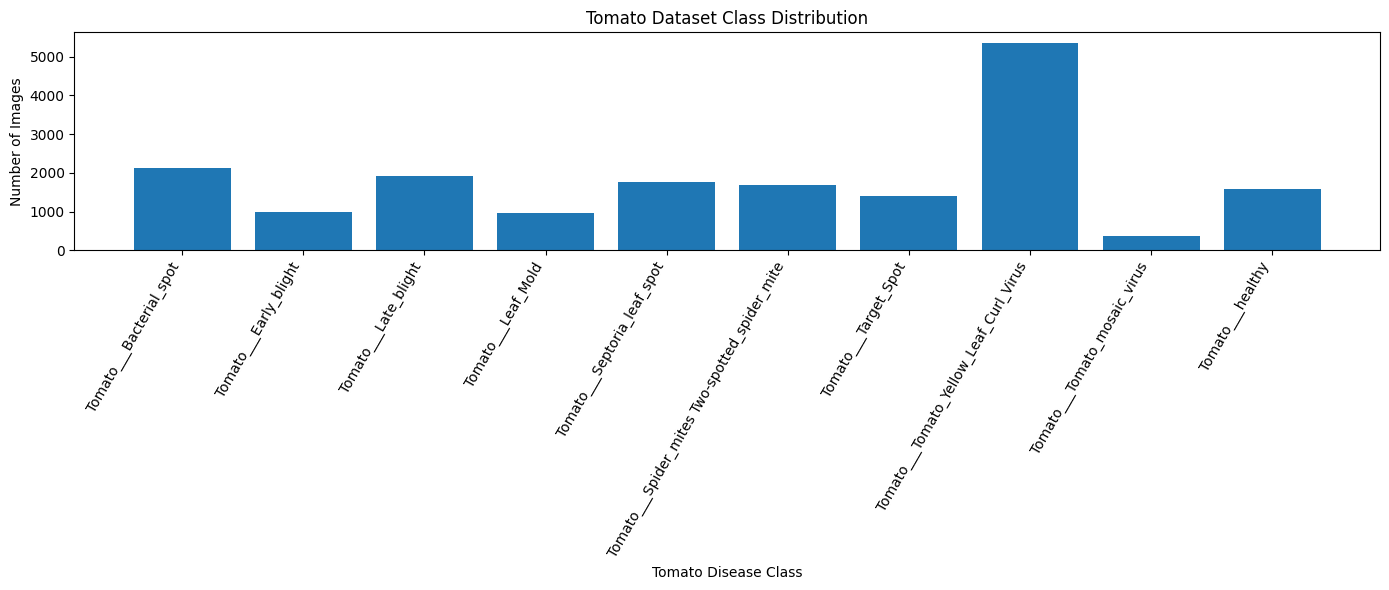

In [32]:
plt.figure(figsize=(14, 6))

plt.bar(
    class_distribution["Class"],
    class_distribution["Number of Images"]
)

plt.xlabel("Tomato Disease Class")
plt.ylabel("Number of Images")
plt.title("Tomato Dataset Class Distribution")

plt.xticks(
    rotation=60,
    ha="right"
)

plt.tight_layout()
plt.show()

## Step 9: Image Preprocessing

The images are resized to 224 × 224 pixels.

A common image size of 224 × 224 is used because it is compatible with both MobileNetV2 and ResNet50 pretrained architectures.

The raw images are retained in the range 0–255 at the dataset level.

Model-specific preprocessing is applied inside the respective models.

Data augmentation is applied only to training images.

In [33]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

all_files = []
all_labels = []

for label, class_name in enumerate(tomato_classes):

    class_path = Path(DATASET_PATH) / class_name

    for file_path in class_path.iterdir():

        if file_path.is_file():

            all_files.append(str(file_path))
            all_labels.append(label)

all_files = np.array(all_files)
all_labels = np.array(all_labels)

print("Total Images:", len(all_files))
print("Total Classes:", len(tomato_classes))

Total Images: 18160
Total Classes: 10


## Step 10: Training, Validation and Testing Split

The dataset is divided into three independent subsets:

- 70% Training
- 15% Validation
- 15% Testing

Stratified splitting is used so that all classes maintain approximately the same proportion across the three subsets.

The test set is kept separate and is used only for final evaluation.

In [34]:
X_train, X_temp, y_train, y_temp = train_test_split(
    all_files,
    all_labels,
    test_size=0.30,
    random_state=SEED,
    stratify=all_labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Training Images  :", len(X_train))
print("Validation Images:", len(X_val))
print("Testing Images   :", len(X_test))

print(
    "\nTotal:",
    len(X_train) + len(X_val) + len(X_test)
)

Training Images  : 12712
Validation Images: 2724
Testing Images   : 2724

Total: 18160


## Step 11: TensorFlow Data Pipeline

The image paths are converted into TensorFlow datasets.

Each image is:

1. Read from disk
2. Decoded
3. Resized to 224 × 224
4. Converted to floating-point format
5. Batched
6. Prefetched for efficient GPU processing

In [35]:
def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    image.set_shape(
        [IMG_SIZE[0], IMG_SIZE[1], 3]
    )

    return image, label


train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (X_val, y_val)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test)
)


train_ds = (
    train_ds
    .shuffle(2000, seed=SEED)
    .map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


val_ds = (
    val_ds
    .map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


test_ds = (
    test_ds
    .map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("TensorFlow datasets created successfully.")

TensorFlow datasets created successfully.


## Step 12: Data Augmentation

Data augmentation is used only during training.

The following transformations are applied:

- Random horizontal flipping
- Random rotation
- Random zoom

These transformations create small variations of the training images and help improve model generalization.

In [36]:
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.15),
        layers.RandomZoom(0.15)
    ],
    name="data_augmentation"
)

print("Data augmentation created.")

Data augmentation created.


## Step 13: Visualize Dataset Samples

Before training, sample images from the training dataset are displayed.

This verifies that the images are loading correctly and that the class labels correspond to the images.

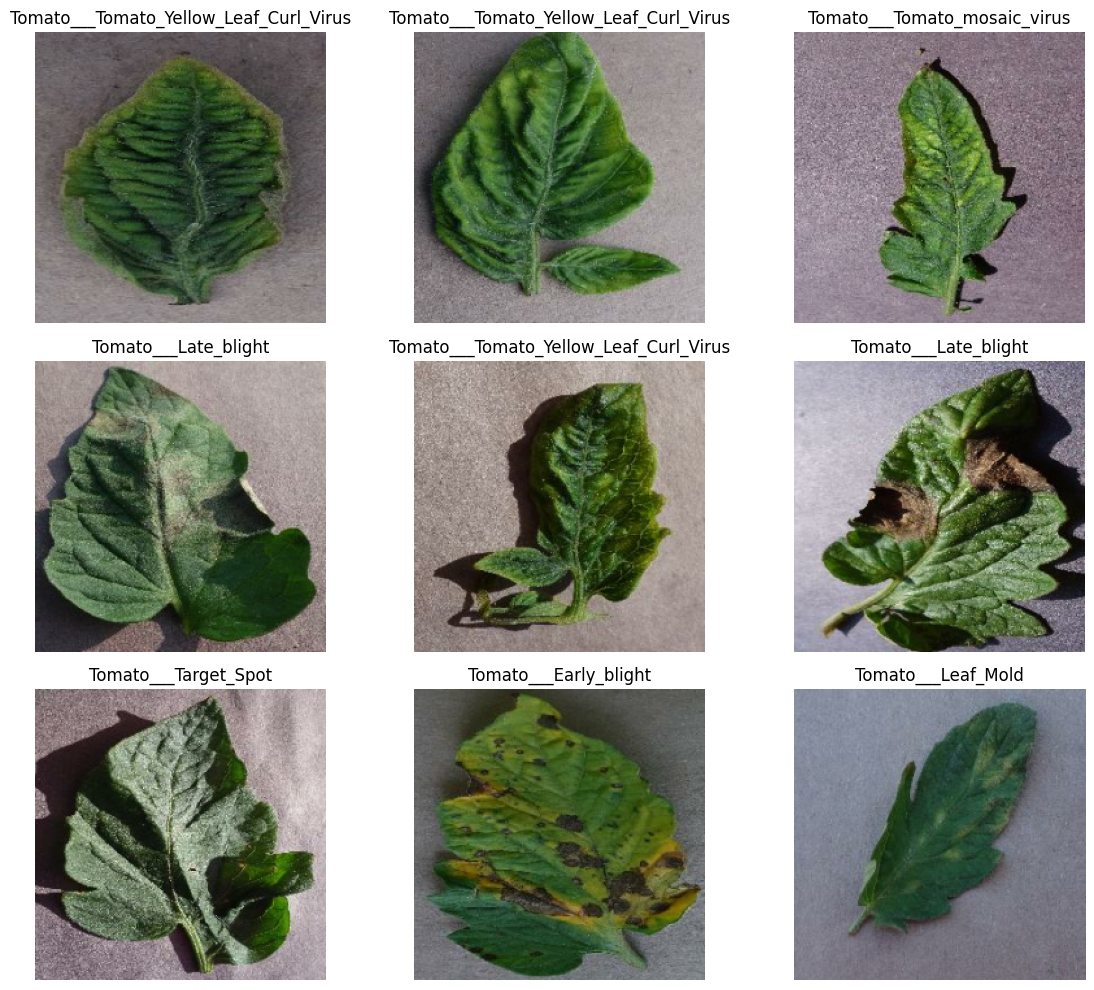

In [37]:
plt.figure(figsize=(12, 10))

for images, labels in train_ds.take(1):

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        plt.title(
            tomato_classes[
                labels[i].numpy()
            ]
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

# Task 2 — Custom CNN Implementation

## Custom CNN Architecture

A CNN is trained from scratch to establish a baseline.

The architecture contains:

- Input layer
- Rescaling layer
- Data augmentation
- Three convolutional layers
- Max-pooling layers
- Flatten layer
- Fully connected layer
- Dropout
- Softmax output layer

The convolutional layers progressively increase the number of filters from 32 to 64 to 128.

This architecture follows the general structure of the custom CNN described in the reference paper, which uses multiple convolutional layers, pooling and a fully connected classification layer.

In [38]:
cnn_model = models.Sequential(
    [

        layers.Input(
            shape=(224, 224, 3)
        ),

        layers.Rescaling(
            1.0 / 255
        ),

        data_augmentation,

        layers.Conv2D(
            32,
            (3, 3),
            activation="relu"
        ),

        layers.MaxPooling2D(
            (2, 2)
        ),

        layers.Conv2D(
            64,
            (3, 3),
            activation="relu"
        ),

        layers.MaxPooling2D(
            (2, 2)
        ),

        layers.Conv2D(
            128,
            (3, 3),
            activation="relu"
        ),

        layers.MaxPooling2D(
            (2, 2)
        ),

        layers.Flatten(),

        layers.Dense(
            64,
            activation="relu"
        ),

        layers.Dropout(
            0.3
        ),

        layers.Dense(
            len(tomato_classes),
            activation="softmax"
        )
    ],
    name="Custom_CNN"
)


cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)


cnn_model.summary()

Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     5,537,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,631,754 (21.48 MB)

 Trainable params: 5,631,754 (21.48 MB)

 Non-trainable params: 0 (0.00 B)

## CNN Training

The custom CNN is trained from scratch for a maximum of 10 epochs.

Early stopping is used to stop training if the validation loss does not improve for two consecutive epochs.

The training time is recorded for comparison with MobileNetV2 and ResNet50.

In [39]:
early_stop_cnn = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

start_cnn = time.time()

history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop_cnn]
)

cnn_time = time.time() - start_cnn

print(
    "\nCNN Training Time:",
    round(cnn_time, 2),
    "seconds"
)

print(
    "CNN Epochs Completed:",
    len(
        history_cnn.history["accuracy"]
    )
)

Epoch 1/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 27s 62ms/step - accuracy: 0.5015 - loss: 1.4567 - val_accuracy: 0.6927 - val_loss: 0.9357
Epoch 2/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 28s 69ms/step - accuracy: 0.6669 - loss: 0.9541 - val_accuracy: 0.6189 - val_loss: 0.9924
Epoch 3/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 25s 63ms/step - accuracy: 0.7291 - loss: 0.7707 - val_accuracy: 0.7460 - val_loss: 0.7685
Epoch 4/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 41s 63ms/step - accuracy: 0.7472 - loss: 0.7155 - val_accuracy: 0.7801 - val_loss: 0.7170
Epoch 5/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 28s 70ms/step - accuracy: 0.7744 - loss: 0.6379 - val_accuracy: 0.8579 - val_loss: 0.4023
Epoch 6/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 25s 64ms/step - accuracy: 0.7939 - loss: 0.5868 - val_accuracy: 0.7823 - val_loss: 0.6395
Epoch 7/10
398/398 ━━━━━━━━━━━━━━━━━━━━ 25s 63ms/step - accuracy: 0.8161 - loss: 0.5275 - val_accuracy: 0.8319 - val_loss: 0.5119

CNN Training Time: 214.92 seconds
CNN Epochs Completed: 7


## CNN Testing and Evaluation

The trained CNN is evaluated on the independent test set.

The following metrics are calculated:

- Accuracy
- Precision
- Recall
- F1-score

Weighted averaging is used because it accounts for the number of samples belonging to each class.

In [40]:
def evaluate_model(model, dataset):

    y_true = []
    y_pred = []

    for images, labels in dataset:

        predictions = model.predict(
            images,
            verbose=0
        )

        y_true.extend(
            labels.numpy()
        )

        y_pred.extend(
            np.argmax(
                predictions,
                axis=1
            )
        )

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    return (
        y_true,
        y_pred,
        accuracy,
        precision,
        recall,
        f1
    )

In [41]:
(
    y_true_cnn,
    y_pred_cnn,
    cnn_accuracy,
    cnn_precision,
    cnn_recall,
    cnn_f1
) = evaluate_model(
    cnn_model,
    test_ds
)

print("CUSTOM CNN RESULTS")
print("=" * 35)

print(
    "Accuracy :",
    round(cnn_accuracy, 4)
)

print(
    "Precision:",
    round(cnn_precision, 4)
)

print(
    "Recall   :",
    round(cnn_recall, 4)
)

print(
    "F1-score :",
    round(cnn_f1, 4)
)

CUSTOM CNN RESULTS
Accuracy : 0.8704
Precision: 0.8721
Recall   : 0.8704
F1-score : 0.867


## CNN Classification Report

The classification report provides class-wise precision, recall and F1-score.

This allows us to identify which tomato disease categories are classified well and which categories are more difficult for the custom CNN.

In [42]:
print(
    classification_report(
        y_true_cnn,
        y_pred_cnn,
        target_names=tomato_classes,
        zero_division=0
    )
)

                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.95      0.93      0.94       319
                        Tomato___Early_blight       0.77      0.57      0.66       150
                         Tomato___Late_blight       0.86      0.90      0.88       286
                           Tomato___Leaf_Mold       0.92      0.69      0.79       143
                  Tomato___Septoria_leaf_spot       0.85      0.85      0.85       265
Tomato___Spider_mites Two-spotted_spider_mite       0.78      0.84      0.81       252
                         Tomato___Target_Spot       0.76      0.60      0.67       211
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.96      0.97      0.96       804
                 Tomato___Tomato_mosaic_virus       0.70      0.96      0.81        56
                             Tomato___healthy       0.78      1.00      0.87       238

                                     accu

## CNN Confusion Matrix

The confusion matrix shows the relationship between actual and predicted classes.

Correct predictions appear along the diagonal.

Off-diagonal values represent misclassified images.

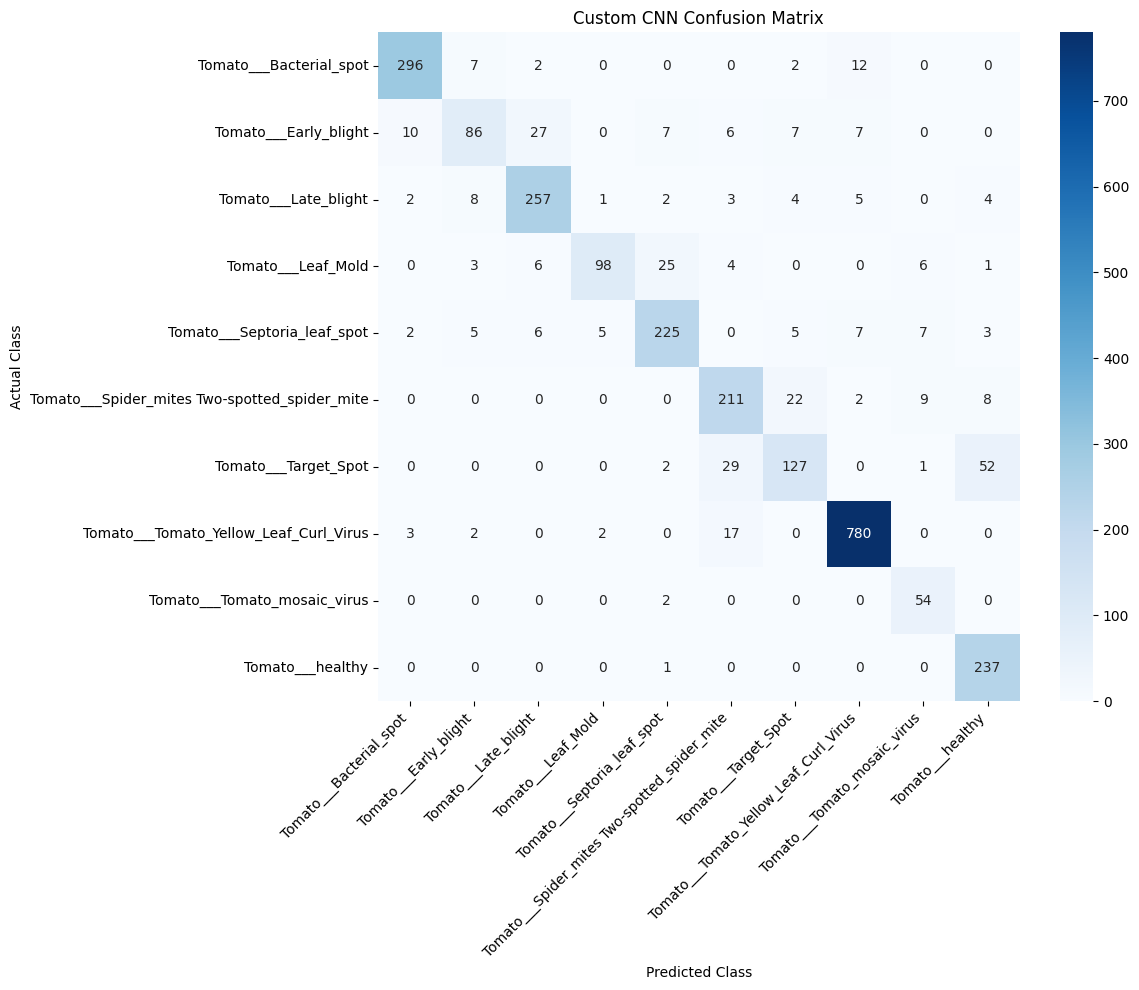

In [43]:
cm_cnn = confusion_matrix(
    y_true_cnn,
    y_pred_cnn
)

plt.figure(
    figsize=(12, 10)
)

sns.heatmap(
    cm_cnn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=tomato_classes,
    yticklabels=tomato_classes
)

plt.title(
    "Custom CNN Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()
plt.show()

## CNN Accuracy and Loss Curves

The training and validation curves are plotted to understand the learning behavior of the custom CNN.

Accuracy curves show classification performance over epochs.

Loss curves show how the prediction error changes during training.

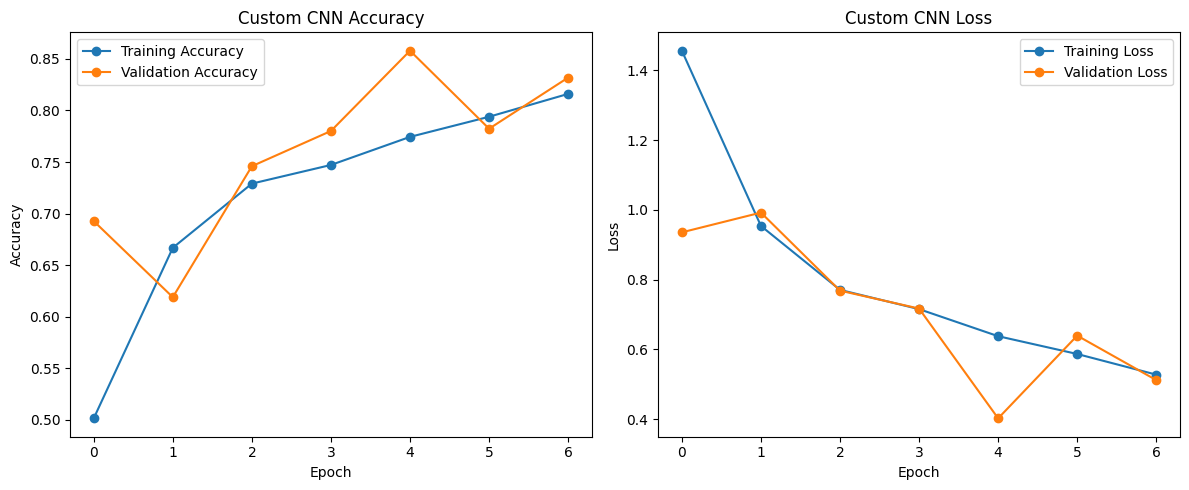

In [44]:
plt.figure(
    figsize=(12, 5)
)

plt.subplot(1, 2, 1)

plt.plot(
    history_cnn.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history_cnn.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title(
    "Custom CNN Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()


plt.subplot(1, 2, 2)

plt.plot(
    history_cnn.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_cnn.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title(
    "Custom CNN Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.tight_layout()
plt.show()

## CNN Feature Map Visualization

Feature maps are visualized from the convolutional layers of the custom CNN.

These feature maps show the intermediate representations learned by the CNN.

The earlier convolutional layers generally capture low-level patterns such as edges and textures, while deeper convolutional layers capture more complex visual patterns related to the classification task.

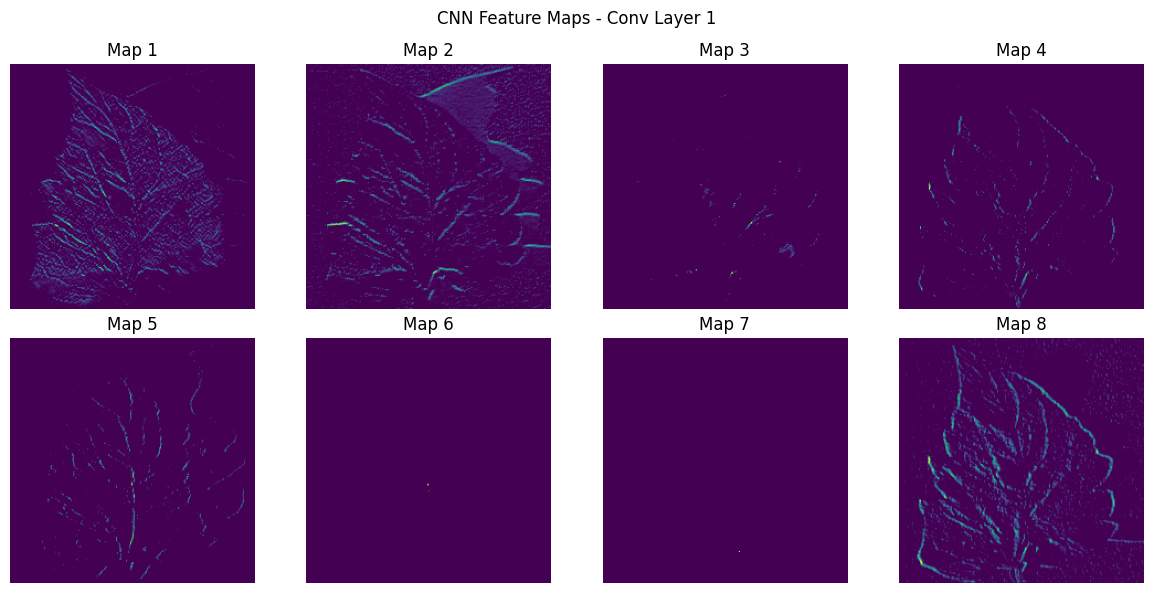

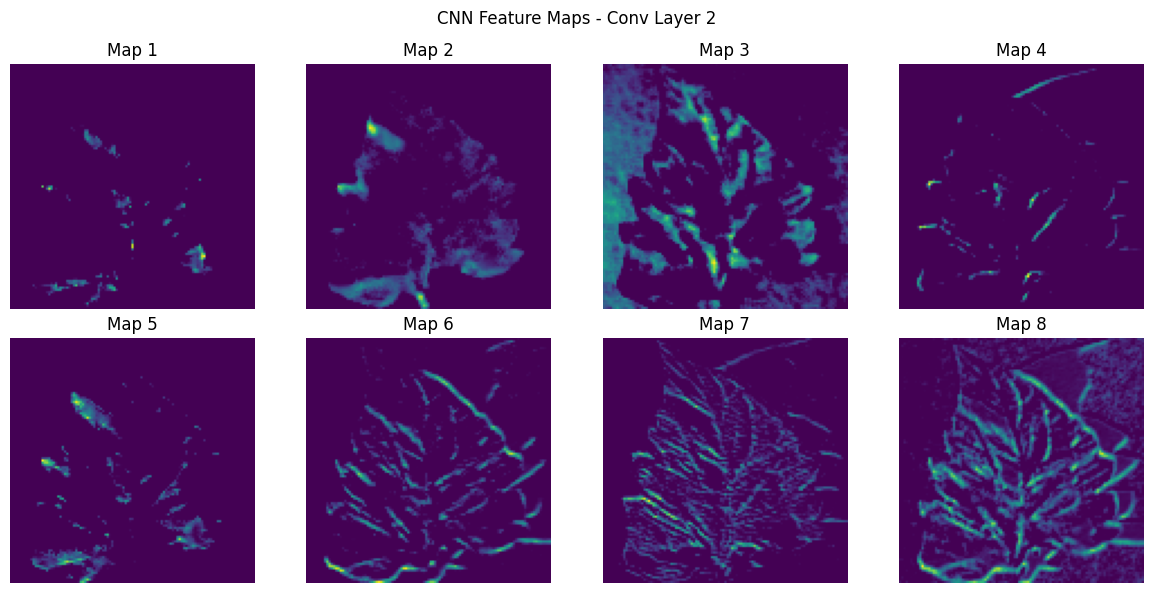

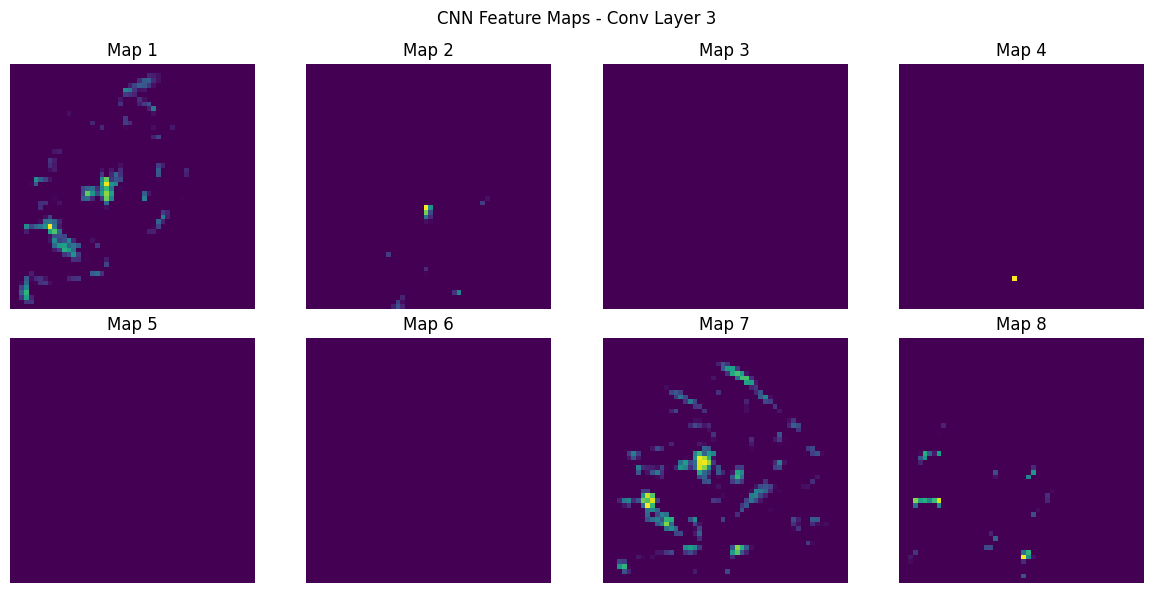

In [75]:
# Create a new symbolic input
feature_input = tf.keras.Input(
    shape=(224, 224, 3)
)

x = feature_input

feature_outputs = []

# Pass the symbolic input through the trained CNN
for layer in cnn_model.layers:

    x = layer(x)

    # Save outputs of convolutional layers
    if isinstance(layer, tf.keras.layers.Conv2D):
        feature_outputs.append(x)


# Create feature extraction model
feature_model = tf.keras.Model(
    inputs=feature_input,
    outputs=feature_outputs
)

# Get one image from the TEST dataset
sample_images, sample_labels = next(
    iter(test_ds)
)

sample_image = sample_images[0:1]

# Generate feature maps
feature_maps = feature_model.predict(
    sample_image,
    verbose=0
)


# Display feature maps

for layer_index, feature_map in enumerate(feature_maps):

    plt.figure(figsize=(12, 6))

    num_maps = min(
        8,
        feature_map.shape[-1]
    )

    for i in range(num_maps):

        plt.subplot(2, 4, i + 1)

        plt.imshow(
            feature_map[0, :, :, i],
            cmap="viridis"
        )

        plt.axis("off")

        plt.title(
            f"Map {i + 1}"
        )

    plt.suptitle(
        f"CNN Feature Maps - Conv Layer {layer_index + 1}"
    )

    plt.tight_layout()
    plt.show()

##TRANSFER LEARNING

## Common Transfer Learning Model Builder

A common function is created so that MobileNetV2 and ResNet50 use the same classification-head design.

This keeps the comparison controlled.

The pretrained convolutional base is followed by:

- Global Average Pooling
- Dropout
- Dense softmax classification layer

In [48]:
def build_transfer_model(
    base_model,
    preprocess_function
):

    base_model.trainable = False

    inputs = tf.keras.Input(
        shape=(224, 224, 3)
    )

    x = data_augmentation(
        inputs
    )

    x = preprocess_function(
        x
    )

    x = base_model(
        x,
        training=False
    )

    x = layers.GlobalAveragePooling2D()(
        x
    )

    x = layers.Dropout(
        0.3
    )(x)

    outputs = layers.Dense(
        len(tomato_classes),
        activation="softmax"
    )(x)

    model = tf.keras.Model(
        inputs,
        outputs
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]
    )

    return model

# Transfer Learning Model 1 — MobileNetV2

## Stage 1: Feature Extraction

The MobileNetV2 convolutional base is loaded with ImageNet pretrained weights.

Initially, all pretrained layers are frozen.

Only the newly added classification head is trained.

A maximum of 5 epochs is used with early stopping.

In [49]:
mobilenet_base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

mobilenet_model = build_transfer_model(
    mobilenet_base,
    mobilenet_preprocess
)

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [50]:
early_stop_mobilenet = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

start_mobilenet_feature = time.time()

history_mobilenet = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[
        early_stop_mobilenet
    ]
)

mobilenet_feature_time = (
    time.time()
    - start_mobilenet_feature
)

print(
    "MobileNetV2 Feature Extraction Time:",
    round(
        mobilenet_feature_time,
        2
    ),
    "seconds"
)

Epoch 1/5
398/398 ━━━━━━━━━━━━━━━━━━━━ 38s 74ms/step - accuracy: 0.7091 - loss: 0.8894 - val_accuracy: 0.8198 - val_loss: 0.5472
Epoch 2/5
398/398 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.8239 - loss: 0.5333 - val_accuracy: 0.8532 - val_loss: 0.4373
Epoch 3/5
398/398 ━━━━━━━━━━━━━━━━━━━━ 29s 72ms/step - accuracy: 0.8461 - loss: 0.4556 - val_accuracy: 0.8693 - val_loss: 0.3899
Epoch 4/5
398/398 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.8591 - loss: 0.4262 - val_accuracy: 0.8781 - val_loss: 0.3758
Epoch 5/5
398/398 ━━━━━━━━━━━━━━━━━━━━ 41s 74ms/step - accuracy: 0.8663 - loss: 0.3978 - val_accuracy: 0.8862 - val_loss: 0.3409
MobileNetV2 Feature Extraction Time: 166.61 seconds


## MobileNetV2 Stage 2: Fine-Tuning

The initial pretrained layers are kept frozen while the top 30 layers are made trainable.

A very small learning rate of 1e-5 is used.

This allows the pretrained features to adapt gradually to the tomato leaf disease dataset while reducing the risk of destroying useful pretrained representations.

The reference paper uses fine-tuning of pretrained models; the exact number of layers to unfreeze is not specified in the paper, so the last 30 layers are an implementation choice for this experiment.

In [51]:
mobilenet_base.trainable = True

for layer in mobilenet_base.layers[:-30]:
    layer.trainable = False


mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)


early_stop_mobilenet_ft = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)


start_mobilenet_ft = time.time()

history_mobilenet_ft = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3,
    callbacks=[
        early_stop_mobilenet_ft
    ]
)

mobilenet_finetune_time = (
    time.time()
    - start_mobilenet_ft
)

mobilenet_total_time = (
    mobilenet_feature_time
    + mobilenet_finetune_time
)

print(
    "MobileNetV2 Fine-Tuning Time:",
    round(
        mobilenet_finetune_time,
        2
    ),
    "seconds"
)

print(
    "MobileNetV2 Total Training Time:",
    round(
        mobilenet_total_time,
        2
    ),
    "seconds"
)

Epoch 1/3
398/398 ━━━━━━━━━━━━━━━━━━━━ 49s 94ms/step - accuracy: 0.7493 - loss: 0.8706 - val_accuracy: 0.8917 - val_loss: 0.3192
Epoch 2/3
398/398 ━━━━━━━━━━━━━━━━━━━━ 36s 91ms/step - accuracy: 0.8516 - loss: 0.4464 - val_accuracy: 0.8950 - val_loss: 0.3122
Epoch 3/3
398/398 ━━━━━━━━━━━━━━━━━━━━ 38s 95ms/step - accuracy: 0.8772 - loss: 0.3686 - val_accuracy: 0.9012 - val_loss: 0.2994
MobileNetV2 Fine-Tuning Time: 123.1 seconds
MobileNetV2 Total Training Time: 289.71 seconds


## MobileNetV2 Testing and Results

The fine-tuned MobileNetV2 is evaluated using the independent test dataset.

Accuracy, precision, recall and F1-score are calculated.

In [52]:
(
    y_true_mobilenet,
    y_pred_mobilenet,
    mobilenet_accuracy,
    mobilenet_precision,
    mobilenet_recall,
    mobilenet_f1
) = evaluate_model(
    mobilenet_model,
    test_ds
)

print("MOBILENETV2 RESULTS")
print("=" * 35)

print(
    "Accuracy :",
    round(mobilenet_accuracy, 4)
)

print(
    "Precision:",
    round(mobilenet_precision, 4)
)

print(
    "Recall   :",
    round(mobilenet_recall, 4)
)

print(
    "F1-score :",
    round(mobilenet_f1, 4)
)

MOBILENETV2 RESULTS
Accuracy : 0.9156
Precision: 0.9172
Recall   : 0.9156
F1-score : 0.9129


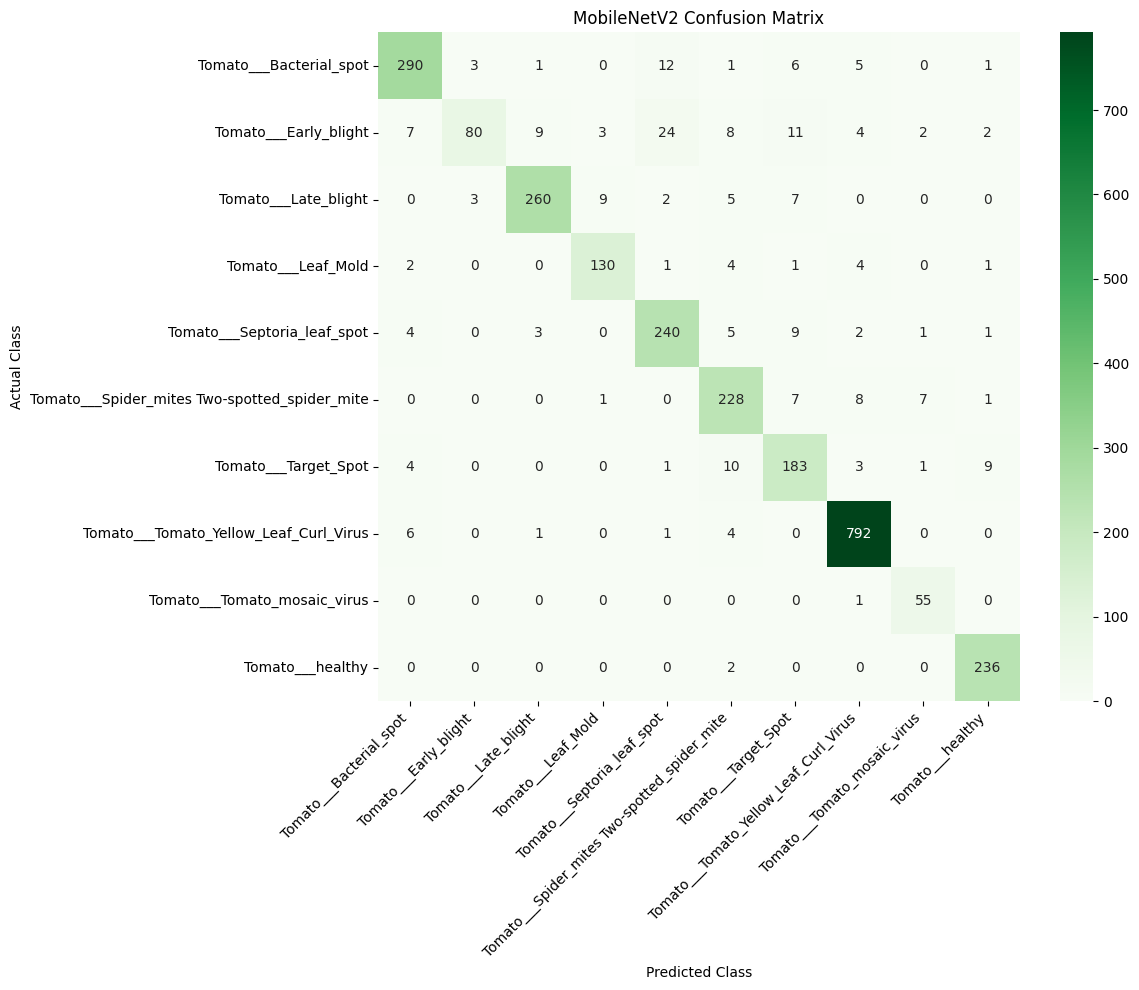

In [53]:
## MobileNetV2 Confusion Matrix
cm_mobilenet = confusion_matrix(
    y_true_mobilenet,
    y_pred_mobilenet
)

plt.figure(
    figsize=(12, 10)
)

sns.heatmap(
    cm_mobilenet,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=tomato_classes,
    yticklabels=tomato_classes
)

plt.title(
    "MobileNetV2 Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()
plt.show()

# Transfer Learning Model 2 — ResNet50

## Stage 1: Feature Extraction

ResNet50 is loaded with ImageNet pretrained weights.

The pretrained convolutional layers are initially frozen.

Only the newly added classification head is trained for a maximum of 5 epochs with early stopping.

In [54]:
resnet_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

resnet_model = build_transfer_model(
    resnet_base,
    resnet_preprocess
)

resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_7[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 10)        │     20,490 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,608,202 (90.06 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [55]:
early_stop_resnet = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

start_resnet_feature = time.time()

history_resnet = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[
        early_stop_resnet
    ]
)

resnet_feature_time = (
    time.time()
    - start_resnet_feature
)

print(
    "ResNet50 Feature Extraction Time:",
    round(
        resnet_feature_time,
        2
    ),
    "seconds"
)

Epoch 1/5
398/398 ━━━━━━━━━━━━━━━━━━━━ 76s 170ms/step - accuracy: 0.7750 - loss: 0.7010 - val_accuracy: 0.8693 - val_loss: 0.3900
Epoch 2/5
398/398 ━━━━━━━━━━━━━━━━━━━━ 77s 193ms/step - accuracy: 0.8980 - loss: 0.3259 - val_accuracy: 0.8759 - val_loss: 0.3575
Epoch 3/5
398/398 ━━━━━━━━━━━━━━━━━━━━ 73s 170ms/step - accuracy: 0.9149 - loss: 0.2686 - val_accuracy: 0.8939 - val_loss: 0.3049
Epoch 4/5
398/398 ━━━━━━━━━━━━━━━━━━━━ 67s 169ms/step - accuracy: 0.9253 - loss: 0.2306 - val_accuracy: 0.9049 - val_loss: 0.2759
Epoch 5/5
398/398 ━━━━━━━━━━━━━━━━━━━━ 67s 169ms/step - accuracy: 0.9305 - loss: 0.2110 - val_accuracy: 0.9247 - val_loss: 0.2252
ResNet50 Feature Extraction Time: 375.07 seconds


## ResNet50 Stage 2: Fine-Tuning

The top 30 layers of ResNet50 are unfrozen.

A learning rate of 1e-5 is used for fine-tuning.

The remaining layers stay frozen to preserve the general ImageNet features learned by the network.

In [56]:
resnet_base.trainable = True

for layer in resnet_base.layers[:-30]:
    layer.trainable = False


resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)


early_stop_resnet_ft = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)


start_resnet_ft = time.time()

history_resnet_ft = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3,
    callbacks=[
        early_stop_resnet_ft
    ]
)

resnet_finetune_time = (
    time.time()
    - start_resnet_ft
)

resnet_total_time = (
    resnet_feature_time
    + resnet_finetune_time
)

print(
    "ResNet50 Fine-Tuning Time:",
    round(
        resnet_finetune_time,
        2
    ),
    "seconds"
)

print(
    "ResNet50 Total Training Time:",
    round(
        resnet_total_time,
        2
    ),
    "seconds"
)

Epoch 1/3
398/398 ━━━━━━━━━━━━━━━━━━━━ 104s 229ms/step - accuracy: 0.8888 - loss: 0.3744 - val_accuracy: 0.9258 - val_loss: 0.2225
Epoch 2/3
398/398 ━━━━━━━━━━━━━━━━━━━━ 87s 219ms/step - accuracy: 0.9473 - loss: 0.1569 - val_accuracy: 0.9391 - val_loss: 0.1861
Epoch 3/3
398/398 ━━━━━━━━━━━━━━━━━━━━ 87s 220ms/step - accuracy: 0.9598 - loss: 0.1200 - val_accuracy: 0.9468 - val_loss: 0.1611
ResNet50 Fine-Tuning Time: 278.82 seconds
ResNet50 Total Training Time: 653.89 seconds


## ResNet50 Testing and Results

The fine-tuned ResNet50 is evaluated on the independent test dataset.

Accuracy, precision, recall and F1-score are calculated.

In [57]:
(
    y_true_resnet,
    y_pred_resnet,
    resnet_accuracy,
    resnet_precision,
    resnet_recall,
    resnet_f1
) = evaluate_model(
    resnet_model,
    test_ds
)

print("RESNET50 RESULTS")
print("=" * 35)

print(
    "Accuracy :",
    round(resnet_accuracy, 4)
)

print(
    "Precision:",
    round(resnet_precision, 4)
)

print(
    "Recall   :",
    round(resnet_recall, 4)
)

print(
    "F1-score :",
    round(resnet_f1, 4)
)

RESNET50 RESULTS
Accuracy : 0.9493
Precision: 0.9517
Recall   : 0.9493
F1-score : 0.949


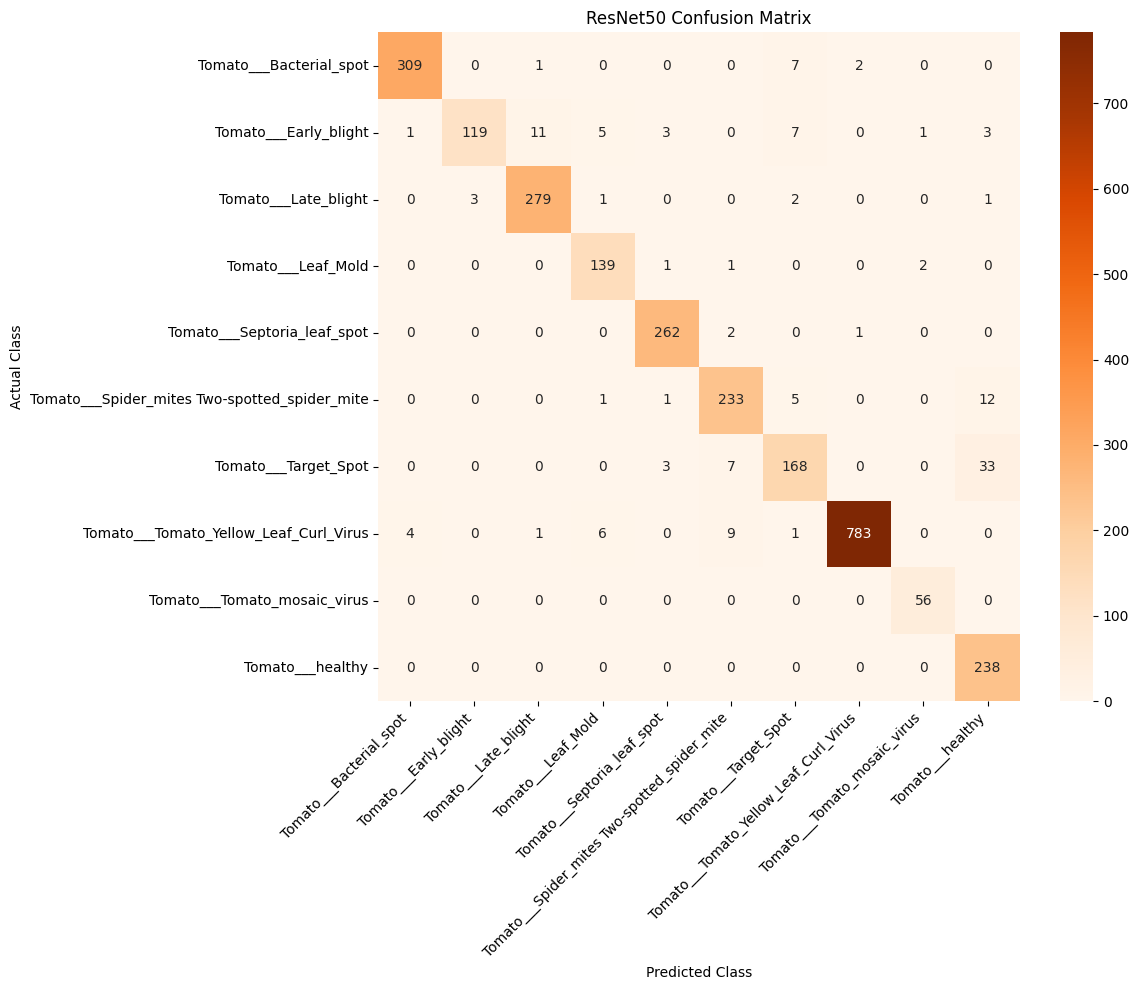

In [58]:
## ResNet50 Confusion Matrix
cm_resnet = confusion_matrix(
    y_true_resnet,
    y_pred_resnet
)

plt.figure(
    figsize=(12, 10)
)

sns.heatmap(
    cm_resnet,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=tomato_classes,
    yticklabels=tomato_classes
)

plt.title(
    "ResNet50 Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()
plt.show()

# Training Curves

The training histories of the custom CNN, MobileNetV2 and ResNet50 are compared.

For MobileNetV2 and ResNet50, the feature-extraction and fine-tuning histories are combined so that the complete training process can be visualized.

The plots show validation accuracy and validation loss for all three models.

In [59]:
def combine_histories(
    feature_history,
    fine_tune_history
):

    accuracy = (
        feature_history.history["accuracy"]
        + fine_tune_history.history["accuracy"]
    )

    val_accuracy = (
        feature_history.history["val_accuracy"]
        + fine_tune_history.history["val_accuracy"]
    )

    loss = (
        feature_history.history["loss"]
        + fine_tune_history.history["loss"]
    )

    val_loss = (
        feature_history.history["val_loss"]
        + fine_tune_history.history["val_loss"]
    )

    return (
        accuracy,
        val_accuracy,
        loss,
        val_loss
    )


(
    mobilenet_acc,
    mobilenet_val_acc,
    mobilenet_loss,
    mobilenet_val_loss
) = combine_histories(
    history_mobilenet,
    history_mobilenet_ft
)


(
    resnet_acc,
    resnet_val_acc,
    resnet_loss,
    resnet_val_loss
) = combine_histories(
    history_resnet,
    history_resnet_ft
)

## Validation Accuracy Comparison

Validation accuracy is plotted for all three approaches.

This allows us to compare how quickly and effectively each model learns the tomato disease classification task.

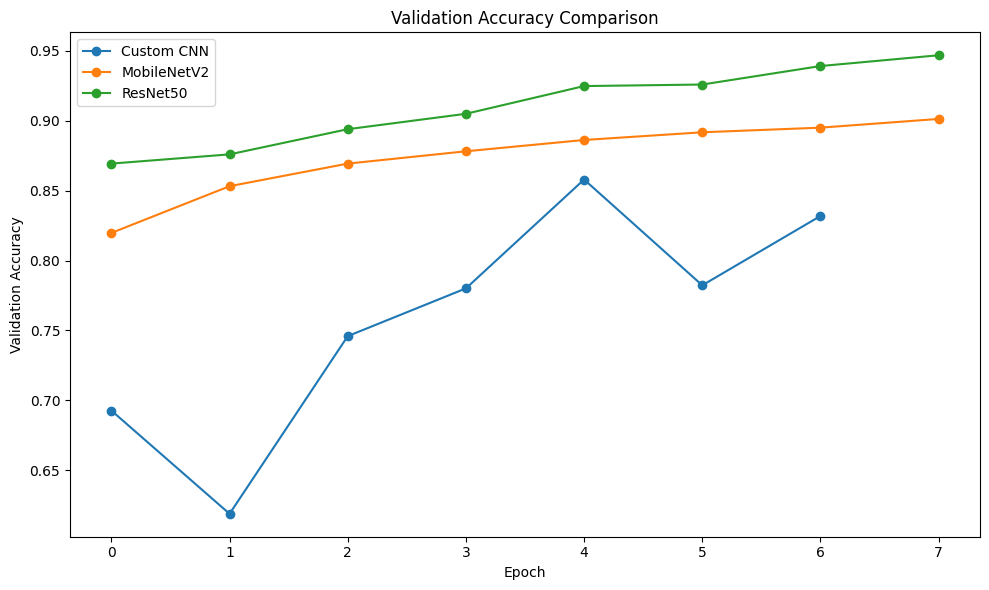

In [60]:
plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_cnn.history["val_accuracy"],
    marker="o",
    label="Custom CNN"
)

plt.plot(
    mobilenet_val_acc,
    marker="o",
    label="MobileNetV2"
)

plt.plot(
    resnet_val_acc,
    marker="o",
    label="ResNet50"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.title(
    "Validation Accuracy Comparison"
)

plt.legend()

plt.tight_layout()
plt.show()

## Validation Loss Comparison

Validation loss is plotted for all three models.

Lower validation loss generally indicates better agreement between predictions and actual labels.

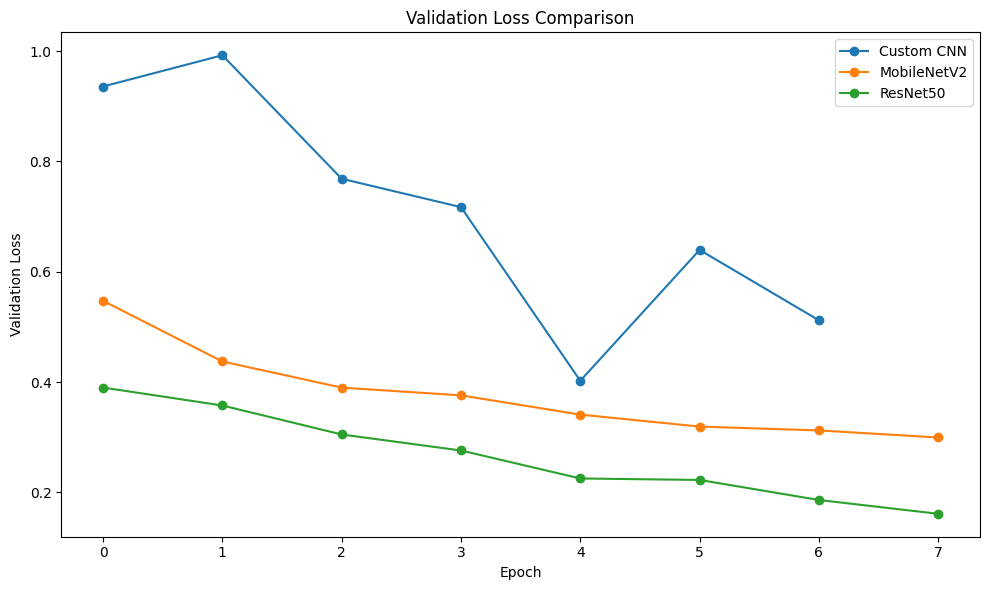

In [61]:
plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_cnn.history["val_loss"],
    marker="o",
    label="Custom CNN"
)

plt.plot(
    mobilenet_val_loss,
    marker="o",
    label="MobileNetV2"
)

plt.plot(
    resnet_val_loss,
    marker="o",
    label="ResNet50"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

plt.title(
    "Validation Loss Comparison"
)

plt.legend()

plt.tight_layout()
plt.show()

# Task 3 — Model Evaluation and Performance Comparison

The three approaches are now compared using:

- Accuracy
- Precision
- Recall
- F1-score
- Training time
- Number of parameters
- Model complexity
- Accuracy curves
- Loss curves
- Confusion matrices

The purpose is to identify which model provides the best classification performance and which model provides the best computational efficiency.

## Parameter Count

Model complexity is measured using the total number of parameters and the number of trainable parameters.

Trainable parameters are especially relevant after fine-tuning because only a portion of the pretrained network is updated.

In [62]:
def get_parameter_counts(model):

    total_params = np.sum([
        np.prod(v.shape)
        for v in model.weights
    ])

    trainable_params = np.sum([
        np.prod(v.shape)
        for v in model.trainable_weights
    ])

    non_trainable_params = (
        total_params
        - trainable_params
    )

    return (
        int(total_params),
        int(trainable_params),
        int(non_trainable_params)
    )


cnn_total, cnn_trainable, cnn_nontrainable = (
    get_parameter_counts(cnn_model)
)

mobilenet_total, mobilenet_trainable, mobilenet_nontrainable = (
    get_parameter_counts(mobilenet_model)
)

resnet_total, resnet_trainable, resnet_nontrainable = (
    get_parameter_counts(resnet_model)
)


print("Custom CNN")
print(
    cnn_total,
    cnn_trainable,
    cnn_nontrainable
)

print("\nMobileNetV2")
print(
    mobilenet_total,
    mobilenet_trainable,
    mobilenet_nontrainable
)

print("\nResNet50")
print(
    resnet_total,
    resnet_trainable,
    resnet_nontrainable
)

Custom CNN
5631754 5631754 0

MobileNetV2
2270794 1539210 731584

ResNet50
23608202 14470666 9137536


## Final Performance Comparison

The following table summarizes the experimental results of all three models.

The results are generated from the independent test dataset.

This is important because the values in this table are our experimental results and should not be confused with the results reported in the reference paper.

In [63]:
results = pd.DataFrame({

    "Model": [
        "Custom CNN",
        "MobileNetV2",
        "ResNet50"
    ],

    "Accuracy": [
        cnn_accuracy,
        mobilenet_accuracy,
        resnet_accuracy
    ],

    "Precision": [
        cnn_precision,
        mobilenet_precision,
        resnet_precision
    ],

    "Recall": [
        cnn_recall,
        mobilenet_recall,
        resnet_recall
    ],

    "F1-score": [
        cnn_f1,
        mobilenet_f1,
        resnet_f1
    ],

    "Training Time (sec)": [
        cnn_time,
        mobilenet_total_time,
        resnet_total_time
    ],

    "Total Parameters": [
        cnn_total,
        mobilenet_total,
        resnet_total
    ],

    "Trainable Parameters": [
        cnn_trainable,
        mobilenet_trainable,
        resnet_trainable
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-score,Training Time (sec),Total Parameters,Trainable Parameters
0,Custom CNN,0.870411,0.872089,0.870411,0.867021,214.922193,5631754,5631754
1,MobileNetV2,0.915565,0.917153,0.915565,0.912932,289.708565,2270794,1539210
2,ResNet50,0.949339,0.951702,0.949339,0.949006,653.889929,23608202,14470666


## Accuracy Comparison

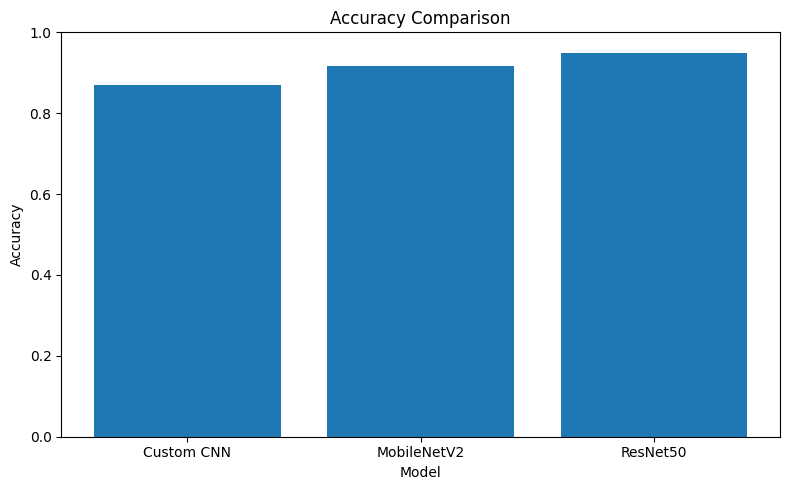

In [64]:
plt.figure(
    figsize=(8, 5)
)

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.title(
    "Accuracy Comparison"
)

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

## Precision, Recall and F1-score Comparison

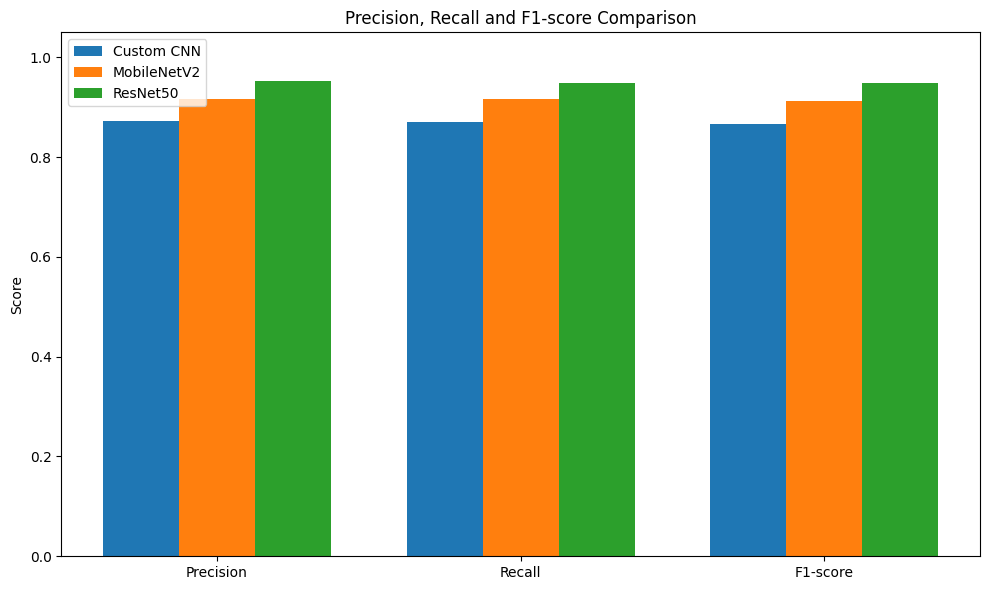

In [65]:
metric_names = [
    "Precision",
    "Recall",
    "F1-score"
]

x = np.arange(
    len(metric_names)
)

width = 0.25

plt.figure(
    figsize=(10, 6)
)

for i, model_name in enumerate(
    results["Model"]
):

    model_values = results.loc[
        results["Model"] == model_name,
        metric_names
    ].values[0]

    plt.bar(
        x + (i - 1) * width,
        model_values,
        width,
        label=model_name
    )

plt.xticks(
    x,
    metric_names
)

plt.ylabel("Score")

plt.title(
    "Precision, Recall and F1-score Comparison"
)

plt.ylim(0, 1.05)

plt.legend()

plt.tight_layout()
plt.show()

## Training Time Comparison

Training time is compared to study computational efficiency.

A smaller training time can be beneficial when computational resources are limited.

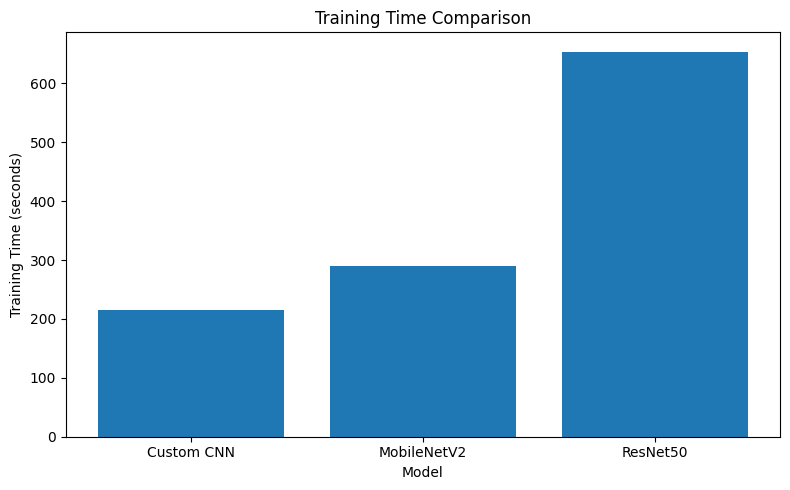

In [66]:
plt.figure(
    figsize=(8, 5)
)

plt.bar(
    results["Model"],
    results["Training Time (sec)"]
)

plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")

plt.title(
    "Training Time Comparison"
)

plt.tight_layout()
plt.show()

## Model Complexity Comparison

The number of parameters is compared to understand the relative model complexity.

The reference paper similarly uses trainable parameter count as an important measure of model complexity.

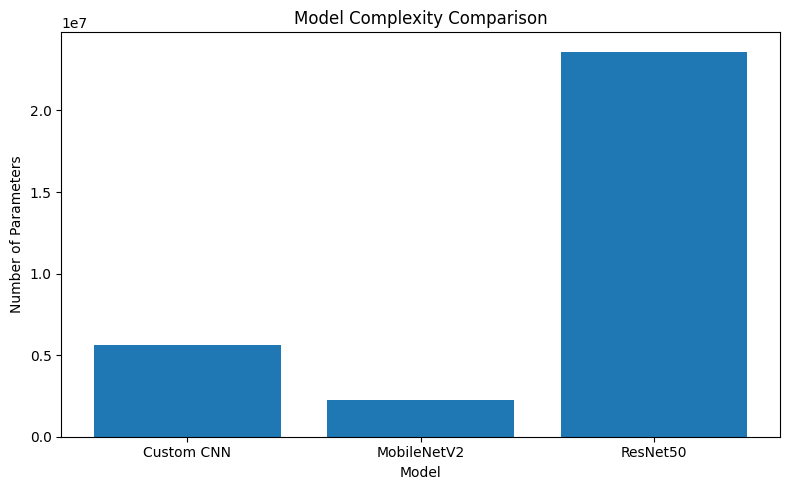

In [67]:
plt.figure(
    figsize=(8, 5)
)

plt.bar(
    results["Model"],
    results["Total Parameters"]
)

plt.xlabel("Model")
plt.ylabel("Number of Parameters")

plt.title(
    "Model Complexity Comparison"
)

plt.tight_layout()
plt.show()

# Final Results and Conclusion

The final comparison identifies the model that performs best on the independent test dataset.

The conclusion considers both classification performance and computational efficiency.

The model with the highest accuracy is not automatically considered the best overall model.

A practical choice also considers:

- Precision
- Recall
- F1-score
- Training time
- Number of parameters
- Deployment requirements

In [68]:
best_accuracy_model = results.loc[
    results["Accuracy"].idxmax(),
    "Model"
]

best_f1_model = results.loc[
    results["F1-score"].idxmax(),
    "Model"
]

fastest_model = results.loc[
    results["Training Time (sec)"].idxmin(),
    "Model"
]

smallest_model = results.loc[
    results["Total Parameters"].idxmin(),
    "Model"
]


print("=" * 60)
print("FINAL EXPERIMENTAL RESULTS")
print("=" * 60)

print(
    "\nHighest Accuracy:",
    best_accuracy_model
)

print(
    "Highest F1-score:",
    best_f1_model
)

print(
    "Fastest Training:",
    fastest_model
)

print(
    "Lowest Parameter Count:",
    smallest_model
)

print("\nComplete Results:")
print(
    results.to_string(
        index=False
    )
)

FINAL EXPERIMENTAL RESULTS

Highest Accuracy: ResNet50
Highest F1-score: ResNet50
Fastest Training: Custom CNN
Lowest Parameter Count: MobileNetV2

Complete Results:
      Model  Accuracy  Precision   Recall  F1-score  Training Time (sec)  Total Parameters  Trainable Parameters
 Custom CNN  0.870411   0.872089 0.870411  0.867021           214.922193           5631754               5631754
MobileNetV2  0.915565   0.917153 0.915565  0.912932           289.708565           2270794               1539210
   ResNet50  0.949339   0.951702 0.949339  0.949006           653.889929          23608202              14470666


# Final Prediction Demonstration

Instead of manually uploading an image, a sample image is automatically selected from the independent test dataset.

The same test-set image, which was not used during model training, is given to all three models:

- Custom CNN
- MobileNetV2
- ResNet50

The true class and the predicted class with confidence score are displayed for each model.

This provides a direct comparison of the three trained models on the same test image.

Selected Test Image:
/content/plantvillage_dataset/plantvillage dataset/color/Tomato___Tomato_Yellow_Leaf_Curl_Virus/5eda1da1-e02d-4d28-ae3f-ab4073f81b78___YLCV_GCREC 2517.JPG

True Class:
Tomato___Tomato_Yellow_Leaf_Curl_Virus


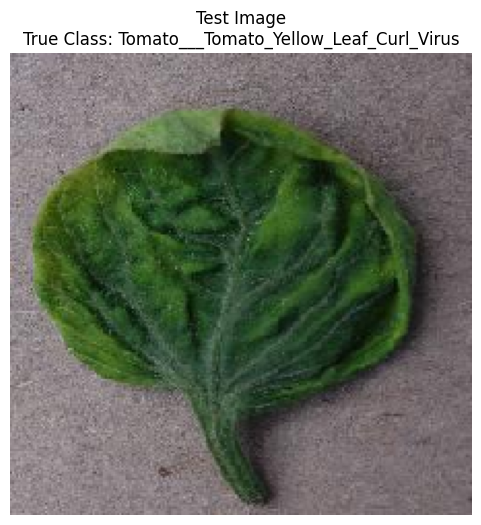

PREDICTION RESULTS
Custom CNN      → Tomato___Tomato_Yellow_Leaf_Curl_Virus (99.99%)
MobileNetV2     → Tomato___Tomato_Yellow_Leaf_Curl_Virus (100.00%)
ResNet50        → Tomato___Tomato_Yellow_Leaf_Curl_Virus (100.00%)

Prediction Summary:


,Model,Predicted Class,Confidence (%)
0,Custom CNN,Tomato___Tomato_Yellow_Leaf_Curl_Virus,99.991516
1,MobileNetV2,Tomato___Tomato_Yellow_Leaf_Curl_Virus,99.999985
2,ResNet50,Tomato___Tomato_Yellow_Leaf_Curl_Virus,99.999977


In [72]:
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array

# --------------------------------------------------
# Select one image automatically from the test set
# --------------------------------------------------

random.seed(42)

sample_index = random.randrange(len(X_test))

sample_path = X_test[sample_index]
true_label = y_test[sample_index]

true_class = tomato_classes[true_label]

print("Selected Test Image:")
print(sample_path)
print("\nTrue Class:")
print(true_class)


# --------------------------------------------------
# Load and display the image
# --------------------------------------------------

img = load_img(
    sample_path,
    target_size=IMG_SIZE
)

img_array = img_to_array(img)

input_image = np.expand_dims(
    img_array,
    axis=0
)


plt.figure(figsize=(6, 6))

plt.imshow(img)

plt.title(
    f"Test Image\nTrue Class: {true_class}"
)

plt.axis("off")

plt.show()


# --------------------------------------------------
# Models
# --------------------------------------------------

models_to_test = {
    "Custom CNN": cnn_model,
    "MobileNetV2": mobilenet_model,
    "ResNet50": resnet_model
}


# --------------------------------------------------
# Prediction
# --------------------------------------------------

print("=" * 70)
print("PREDICTION RESULTS")
print("=" * 70)

prediction_results = []


for model_name, model in models_to_test.items():

    prediction = model.predict(
        input_image,
        verbose=0
    )

    predicted_index = np.argmax(
        prediction[0]
    )

    confidence = (
        prediction[0][predicted_index] * 100
    )

    predicted_class = tomato_classes[
        predicted_index
    ]

    prediction_results.append(
        [
            model_name,
            predicted_class,
            confidence
        ]
    )

    print(
        f"{model_name:15s} → "
        f"{predicted_class} "
        f"({confidence:.2f}%)"
    )


# --------------------------------------------------
# Display results as a table
# --------------------------------------------------

prediction_df = pd.DataFrame(
    prediction_results,
    columns=[
        "Model",
        "Predicted Class",
        "Confidence (%)"
    ]
)

print("\nPrediction Summary:")
display(prediction_df)

# Final Conclusion

The experiment compared a custom CNN trained from scratch with two pretrained transfer-learning models, MobileNetV2 and ResNet50, for tomato leaf disease classification.

The Custom CNN achieved an accuracy of **87.04%**, with an F1-score of **86.70%**.

MobileNetV2 achieved an improved accuracy of **91.56%** and an F1-score of **91.29%** while using only approximately **2.27 million parameters**.

ResNet50 achieved the highest performance with an accuracy of **94.93%**, precision of **95.17%**, recall of **94.93%** and F1-score of **94.90%**.

Therefore, **ResNet50 performed best in terms of classification performance**. Its deeper architecture and pretrained visual representations provided stronger feature extraction for the tomato disease classification task.

However, ResNet50 also required the highest training time (**653.89 seconds**) and had the largest number of parameters (**23.61 million**).

MobileNetV2 provided a useful balance between performance and model complexity. It achieved **91.56% accuracy** with only **2.27 million parameters**, making it a more suitable choice for resource-constrained applications.

The Custom CNN was the fastest model to train (**214.92 seconds**) but produced the lowest classification performance.

Overall, the experiment demonstrates that transfer learning can significantly improve classification performance compared with a CNN trained from scratch. ResNet50 is the best choice when classification accuracy is the primary objective, while MobileNetV2 is preferable when computational efficiency and lower model complexity are important.